In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import norm
from matplotlib.backends.backend_pdf import PdfPages
import argparse
import sys
from matplotlib import rc, rcParams
import matplotlib.ticker as mticker
import lhapdf

# global plotting settings
FONTSIZE = 18 #18 standart 24 for three plots in a row

# matplotlib settings
plt.rc("font", family="serif", size=FONTSIZE, serif="Charter")
plt.rc("axes", titlesize=FONTSIZE)
# plt.rc("text.latex", preamble=r"\usepackage{amsmath}\usepackage[bitstream-charter]{mathdesign}")
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage{amsmath}
\usepackage[bitstream-charter]{mathdesign}
\DeclareSymbolFont{usualmathcal}{OMS}{cmsy}{m}{n}
\DeclareSymbolFontAlphabet{\mathcal}{usualmathcal}
"""
)
plt.rc("text", usetex=True)
# rc('xtick', labelsize=FONTSIZE)
rc('ytick', labelsize=FONTSIZE)

rcParams["errorbar.capsize"] = 7.0
rcParams['legend.frameon']=False
rcParams['legend.handlelength']=1.0


# L1 data tests

In [2]:
data = np.load("Dataset/data_208.npz")

# -----------------------
# Extract arrays
# -----------------------
xgrid = data["xgrid"]
y_theory = data["y_theory"]
y_pseudo = data["y_pseudo"]
xt3_true = data["xt3_true"]
q2_vals = data["q2_vals"]

kinematics = data["kinematics"] if "kinematics" in data else None

# Optional reconstructed solution (if present)
xt3_reco = None
xt3_err = None
for key in ["xt3_reco", "xt3_fit", "xt3_mean"]:
    if key in data:
        xt3_reco = data[key]
for key in ["xt3_err", "xt3_std", "xt3_sigma"]:
    if key in data:
        xt3_err = data[key]

# Q0 handling
Q0 = data["Q0"] if "Q0" in data else 2.0  # fallback if not saved

LHAPDF 6.5.5 loading /opt/homebrew/Caskroom/miniconda/base/envs/nnpdf/share/LHAPDF/NNPDF40_nnlo_as_01180/NNPDF40_nnlo_as_01180_0000.dat
NNPDF40_nnlo_as_01180 PDF set, member #0, version 1; LHAPDF ID = 331100


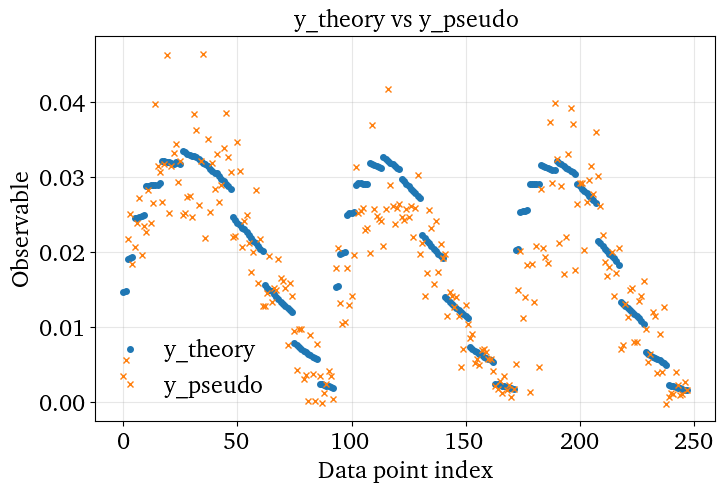

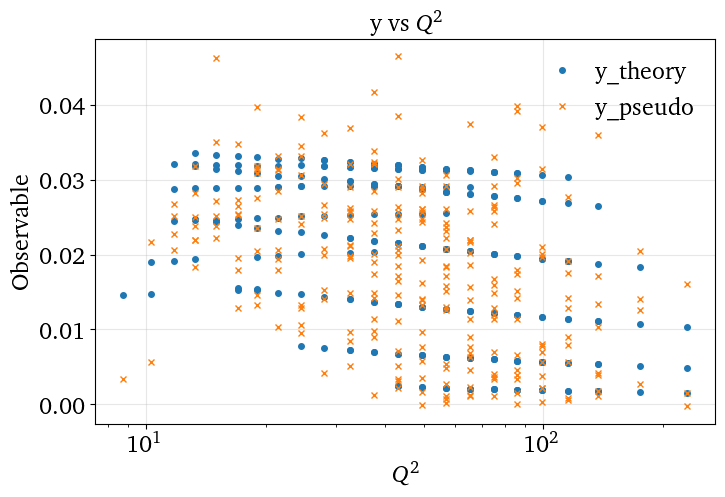

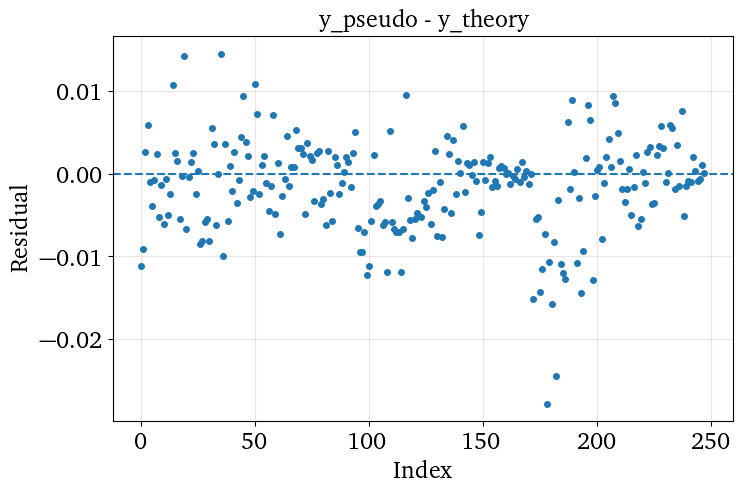

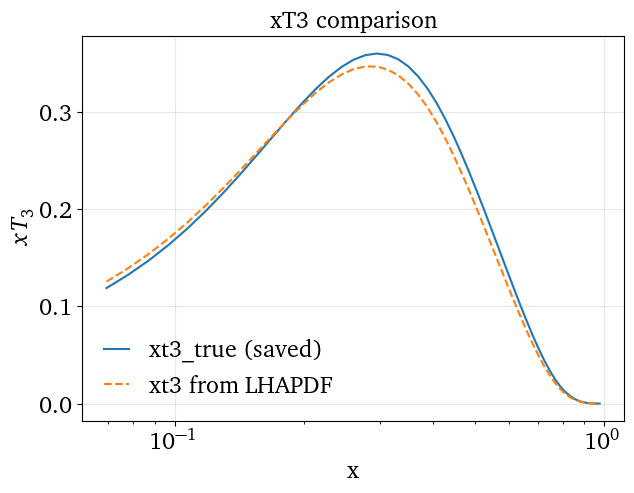

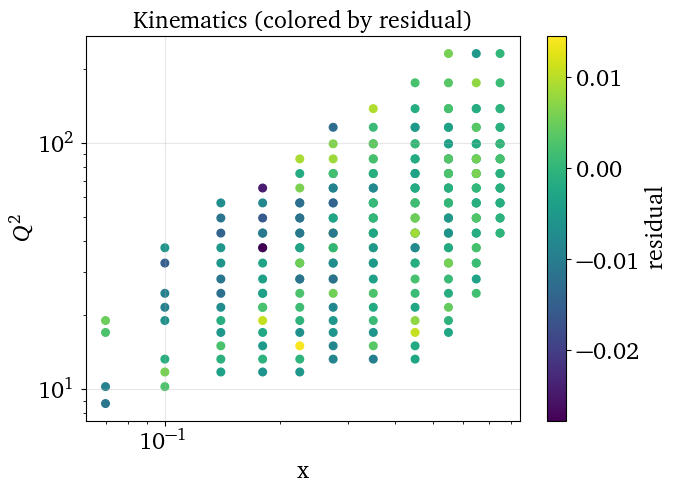

Max |xt3_true - xt3_pdf| = 0.019892608895690334


In [3]:
# Assumes: `data = np.load(...)` already executed
pdf_name = "NNPDF40_nnlo_as_01180"
pdf = lhapdf.getPDFSet(pdf_name).mkPDF(0)

xt3_pdf = np.zeros_like(xgrid)
for i, x in enumerate(xgrid):
    u = pdf.xfxQ(2, x, Q0)
    ub = pdf.xfxQ(-2, x, Q0)
    d = pdf.xfxQ(1, x, Q0)
    db = pdf.xfxQ(-1, x, Q0)
    xt3_pdf[i] = (u + ub) - (d + db)

# -----------------------
# Plot 1: y_theory vs y_pseudo (index)
# -----------------------
plt.figure(figsize=(8, 5))
idx = np.arange(len(y_theory))
plt.plot(idx, y_theory, "o", ms=4, label="y_theory")
plt.plot(idx, y_pseudo, "x", ms=4, label="y_pseudo")
plt.xlabel("Data point index")
plt.ylabel("Observable")
plt.title("y_theory vs y_pseudo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 2: vs Q^2
# -----------------------
order = np.argsort(q2_vals)
plt.figure(figsize=(8, 5))
plt.plot(q2_vals[order], y_theory[order], "o", ms=4, label="y_theory")
plt.plot(q2_vals[order], y_pseudo[order], "x", ms=4, label="y_pseudo")
plt.xscale("log")
plt.xlabel(r"$Q^2$")
plt.ylabel("Observable")
plt.title(r"y vs $Q^2$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 3: residuals
# -----------------------
plt.figure(figsize=(8, 5))
residual = y_pseudo - y_theory
plt.axhline(0.0, linestyle="--")
plt.plot(idx, residual, "o", ms=4)
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("y_pseudo - y_theory")
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 4: xT3 comparison
# -----------------------
plt.figure(figsize=(7, 5))
plt.plot(xgrid, xt3_true, label="xt3_true (saved)")
plt.plot(xgrid, xt3_pdf, "--", label="xt3 from LHAPDF")

if xt3_reco is not None:
    plt.plot(xgrid, xt3_reco, label="xt3 reconstructed")
    if xt3_err is not None:
        plt.fill_between(
            xgrid,
            xt3_reco - xt3_err,
            xt3_reco + xt3_err,
            alpha=0.3,
            label="uncertainty",
        )

plt.xscale("log")
plt.xlabel("x")
plt.ylabel(r"$xT_3$")
plt.title("xT3 comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 5: kinematics (optional)
# -----------------------
if kinematics is not None:
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        kinematics[:, 0],
        kinematics[:, 1],
        c=residual,
        s=30,
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x")
    plt.ylabel(r"$Q^2$")
    plt.title("Kinematics (colored by residual)")
    plt.colorbar(sc, label="residual")
    plt.grid(alpha=0.3)
    plt.show()

# -----------------------
# Quick consistency check
# -----------------------
print("Max |xt3_true - xt3_pdf| =", np.max(np.abs(xt3_true - xt3_pdf)))

In [4]:
data = np.load("Dataset/data_40001000.npz")

# -----------------------
# Extract arrays
# -----------------------
xgrid = data["xgrid"]
y_theory = data["y_theory"]
y_pseudo = data["y_pseudo"]
xt3_true = data["xt3_true"]
q2_vals = data["q2_vals"]

kinematics = data["kinematics"] if "kinematics" in data else None

# Optional reconstructed solution (if present)
xt3_reco = None
xt3_err = None
for key in ["xt3_reco", "xt3_fit", "xt3_mean"]:
    if key in data:
        xt3_reco = data[key]
for key in ["xt3_err", "xt3_std", "xt3_sigma"]:
    if key in data:
        xt3_err = data[key]

# Q0 handling
Q0 = data["Q0"] if "Q0" in data else 2.0  # fallback if not saved

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/data_40001000.npz'

LHAPDF 6.5.5 loading /opt/homebrew/Caskroom/miniconda/base/envs/nnpdf/share/LHAPDF/NNPDF40_nnlo_as_01180/NNPDF40_nnlo_as_01180_0000.dat
NNPDF40_nnlo_as_01180 PDF set, member #0, version 1; LHAPDF ID = 331100


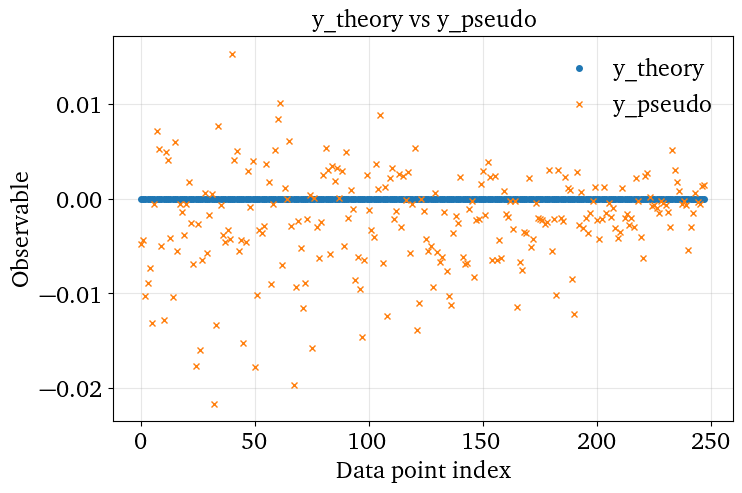

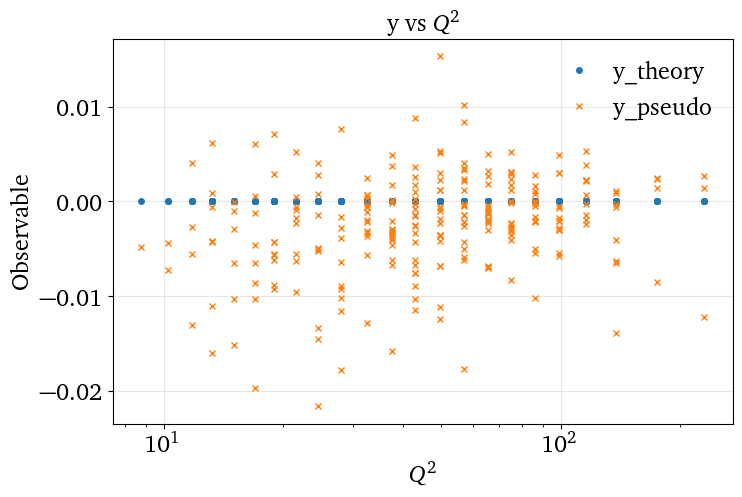

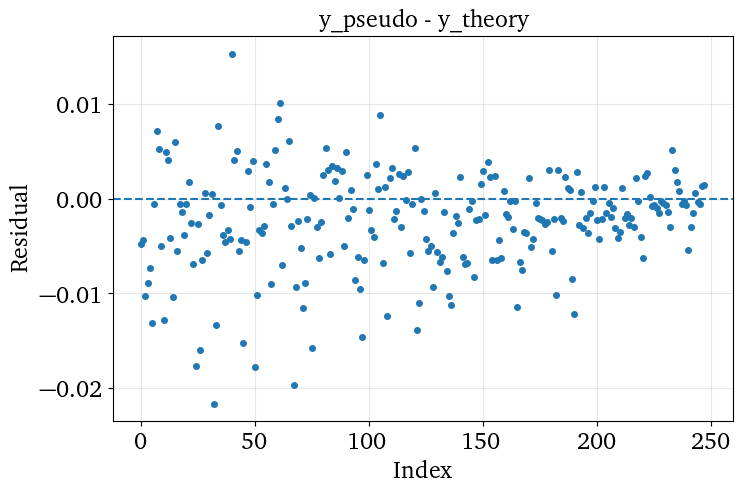

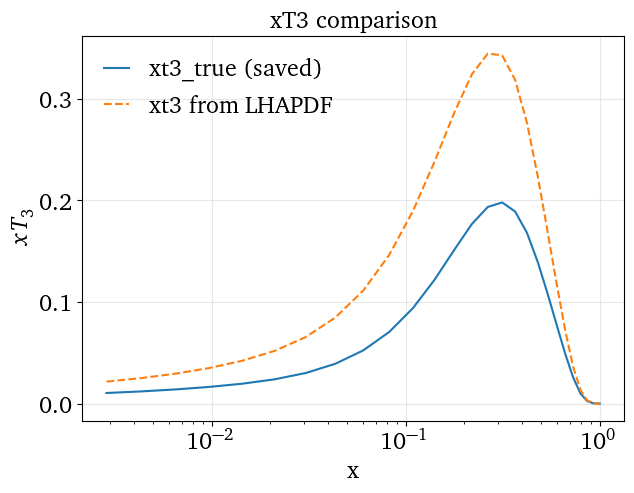

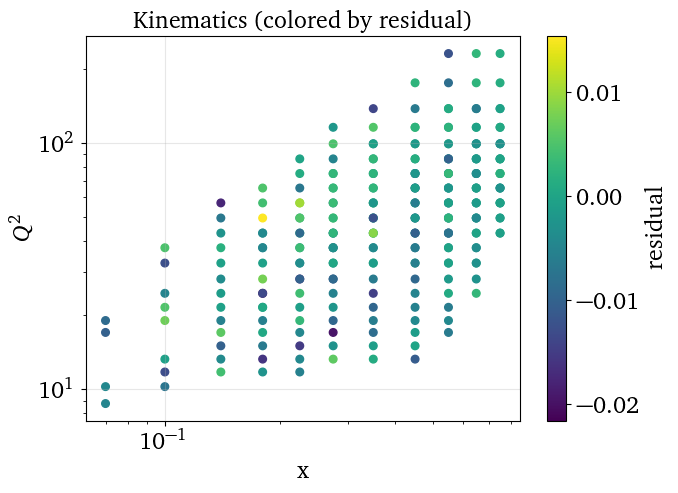

Max |xt3_true - xt3_pdf| = 0.15104701022662367


In [9]:
# Assumes: `data = np.load(...)` already executed
pdf_name = "NNPDF40_nnlo_as_01180"
pdf = lhapdf.getPDFSet(pdf_name).mkPDF(0)

xt3_pdf = np.zeros_like(xgrid)
for i, x in enumerate(xgrid):
    u = pdf.xfxQ(2, x, Q0)
    ub = pdf.xfxQ(-2, x, Q0)
    d = pdf.xfxQ(1, x, Q0)
    db = pdf.xfxQ(-1, x, Q0)
    xt3_pdf[i] = (u + ub) - (d + db)

# -----------------------
# Plot 1: y_theory vs y_pseudo (index)
# -----------------------
plt.figure(figsize=(8, 5))
idx = np.arange(len(y_theory))
plt.plot(idx, y_theory, "o", ms=4, label="y_theory")
plt.plot(idx, y_pseudo, "x", ms=4, label="y_pseudo")
plt.xlabel("Data point index")
plt.ylabel("Observable")
plt.title("y_theory vs y_pseudo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 2: vs Q^2
# -----------------------
order = np.argsort(q2_vals)
plt.figure(figsize=(8, 5))
plt.plot(q2_vals[order], y_theory[order], "o", ms=4, label="y_theory")
plt.plot(q2_vals[order], y_pseudo[order], "x", ms=4, label="y_pseudo")
plt.xscale("log")
plt.xlabel(r"$Q^2$")
plt.ylabel("Observable")
plt.title(r"y vs $Q^2$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 3: residuals
# -----------------------
plt.figure(figsize=(8, 5))
residual = y_pseudo - y_theory
plt.axhline(0.0, linestyle="--")
plt.plot(idx, residual, "o", ms=4)
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("y_pseudo - y_theory")
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 4: xT3 comparison
# -----------------------
plt.figure(figsize=(7, 5))
plt.plot(xgrid, xt3_true, label="xt3_true (saved)")
plt.plot(xgrid, xt3_pdf, "--", label="xt3 from LHAPDF")

if xt3_reco is not None:
    plt.plot(xgrid, xt3_reco, label="xt3 reconstructed")
    if xt3_err is not None:
        plt.fill_between(
            xgrid,
            xt3_reco - xt3_err,
            xt3_reco + xt3_err,
            alpha=0.3,
            label="uncertainty",
        )

plt.xscale("log")
plt.xlabel("x")
plt.ylabel(r"$xT_3$")
plt.title("xT3 comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# Plot 5: kinematics (optional)
# -----------------------
if kinematics is not None:
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        kinematics[:, 0],
        kinematics[:, 1],
        c=residual,
        s=30,
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x")
    plt.ylabel(r"$Q^2$")
    plt.title("Kinematics (colored by residual)")
    plt.colorbar(sc, label="residual")
    plt.grid(alpha=0.3)
    plt.show()

# -----------------------
# Quick consistency check
# -----------------------
print("Max |xt3_true - xt3_pdf| =", np.max(np.abs(xt3_true - xt3_pdf)))

# L2 data tests

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Adapt this path if needed
npz_path = Path("Dataset/data_208_L2.npz")

data = np.load(npz_path, allow_pickle=True)
print("Loaded:", npz_path)
print("Available keys:")
for key in data.files:
    arr = data[key]
    print(f"  {key:20s} shape={arr.shape}, dtype={arr.dtype}")

Loaded: Dataset/data_208_L2.npz
Available keys:
  q2_vals              shape=(248,), dtype=float64
  y_vals               shape=(248,), dtype=float64
  y_pseudo             shape=(248,), dtype=float64
  W                    shape=(248, 50), dtype=float64
  xgrid                shape=(50,), dtype=float64
  y_theory             shape=(248,), dtype=float64
  xt3_true             shape=(50,), dtype=float64
  c_yy                 shape=(248, 248), dtype=float64
  kinematics           shape=(248, 2), dtype=float64
  y_l2                 shape=(20, 248), dtype=float64


In [4]:
# --- Required target array ---
y_l2_key = "y_l2"
y_l2 = np.asarray(data[y_l2_key], dtype=float)

# Make sure shape is (n_replicas, n_points)
if y_l2.ndim != 2:
    raise ValueError(f"Expected y_l2 to be 2D, got shape {y_l2.shape}")

n0, n1 = y_l2.shape
print("Original y_l2 shape:", y_l2.shape)

# Heuristic: usually replicas < points, but your case may be 100 replicas x N points.
# If the first axis is clearly the data-points axis, transpose.
if n0 > n1:
    print("Transposing y_l2 to shape (n_replicas, n_points).")
    y_l2 = y_l2.T

n_replicas, n_points = y_l2.shape
print("Using y_l2 shape:", y_l2.shape)
print("n_replicas:", n_replicas)
print("n_points:", n_points)


Original y_l2 shape: (20, 248)
Using y_l2 shape: (20, 248)
n_replicas: 20
n_points: 248


In [6]:
# --- Find an x/data-space coordinate ---
# Preferred candidates. Edit this list if your file uses another name.
x_candidates = [
    "x", "x_data", "xgrid", "xt3", "X", "kinematics", "kine", "kin",
    "Q2", "q2"
]

x_key = None
for key in x_candidates:
    if key in data.files:
        arr = np.asarray(data[key])
        if arr.ndim == 1 and arr.shape[0] == n_points:
            x_key = key
            break
        if arr.ndim == 2 and arr.shape[0] == n_points:
            x_key = key
            break

if x_key is None:
    print("No matching x-like key found. Using point index as x-axis.")
    x_plot = np.arange(n_points)
    x_label = "data point index"
else:
    x_arr = np.asarray(data[x_key], dtype=float)
    print("Using x key:", x_key, "with shape", x_arr.shape)
    
    if x_arr.ndim == 1:
        x_plot = x_arr
        x_label = x_key
    else:
        # If the coordinate is multi-dimensional kinematics, choose one column.
        # Common choice: first column, often x. Change col_idx if needed.
        col_idx = 0
        x_plot = x_arr[:, col_idx]
        x_label = f"{x_key}[:, {col_idx}]"

# Sort by x for readable connected-line plots
order = np.argsort(x_plot)
x_sorted = x_plot[order]
y_l2_sorted = y_l2[:, order]

# --- Optional central/reference curve ---
central_candidates = ["y_pseudo", "y", "y_l1", "y_central", "central", "mean"]
central_key = None
for key in central_candidates:
    if key in data.files:
        arr = np.asarray(data[key])
        if arr.ndim == 1 and arr.shape[0] == n_points:
            central_key = key
            break

y_central_sorted = None
if central_key is not None:
    y_central_sorted = np.asarray(data[central_key], dtype=float)[order]
    print("Using central/reference key:", central_key)
else:
    print("No central/reference key found. Plotting replica mean instead.")

y_mean = y_l2_sorted.mean(axis=0)
y_std = y_l2_sorted.std(axis=0, ddof=1)



Using x key: kinematics with shape (248, 2)
Using central/reference key: y_pseudo


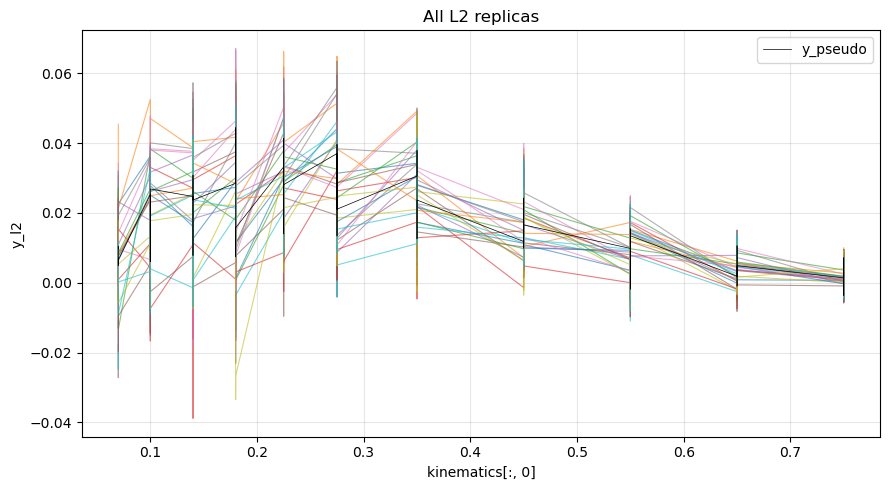

In [10]:
plt.figure(figsize=(9, 5))

for r in range(n_replicas):
    plt.plot(x_sorted, y_l2_sorted[r], linewidth=0.8, alpha=0.6)

if y_central_sorted is not None:
    plt.plot(x_sorted, y_central_sorted, color="black", linewidth=0.5, label=central_key)
else:
    plt.plot(x_sorted, y_mean, color="black", linewidth=2.5, label="replica mean")

plt.xlabel(x_label)
plt.ylabel(y_l2_key)
plt.title("All L2 replicas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


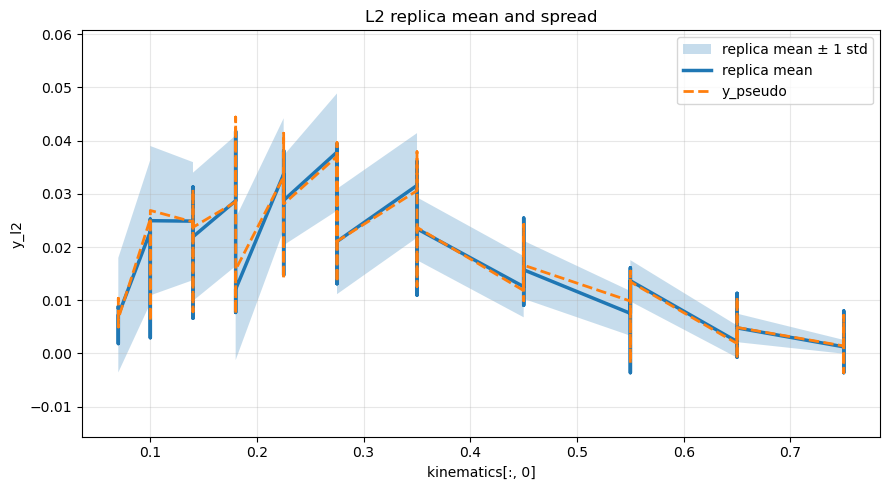

In [11]:
plt.figure(figsize=(9, 5))

plt.fill_between(x_sorted, y_mean - y_std, y_mean + y_std, alpha=0.25, label="replica mean ± 1 std")
plt.plot(x_sorted, y_mean, linewidth=2.5, label="replica mean")

if y_central_sorted is not None:
    plt.plot(x_sorted, y_central_sorted, linestyle="--", linewidth=2.0, label=central_key)

plt.xlabel(x_label)
plt.ylabel(y_l2_key)
plt.title("L2 replica mean and spread")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


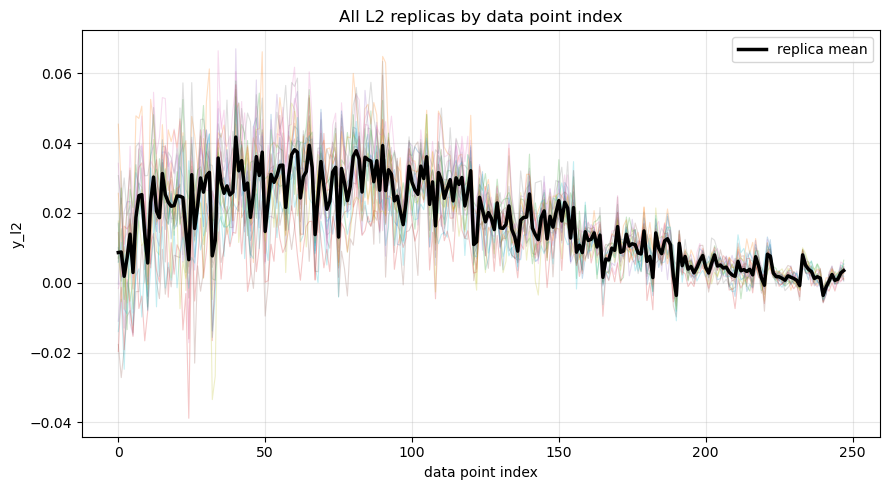

In [12]:
idx = np.arange(n_points)

plt.figure(figsize=(9, 5))
for r in range(n_replicas):
    plt.plot(idx, y_l2[r], linewidth=0.8, alpha=0.25)

plt.plot(idx, y_l2.mean(axis=0), color="black", linewidth=2.5, label="replica mean")
plt.xlabel("data point index")
plt.ylabel(y_l2_key)
plt.title("All L2 replicas by data point index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# L1 samples

In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("Dataset/data_208_l1_samples.npz")

x_data = data["x_data"]

xgrid = data["xgrid"]

y_theory = data["y_theory"]
y_l1_samples = data["y_l1_samples"]
y_l1_std = data["y_l1_std"]

print("L1:", y_l1_samples.shape)

L1: (10, 248)


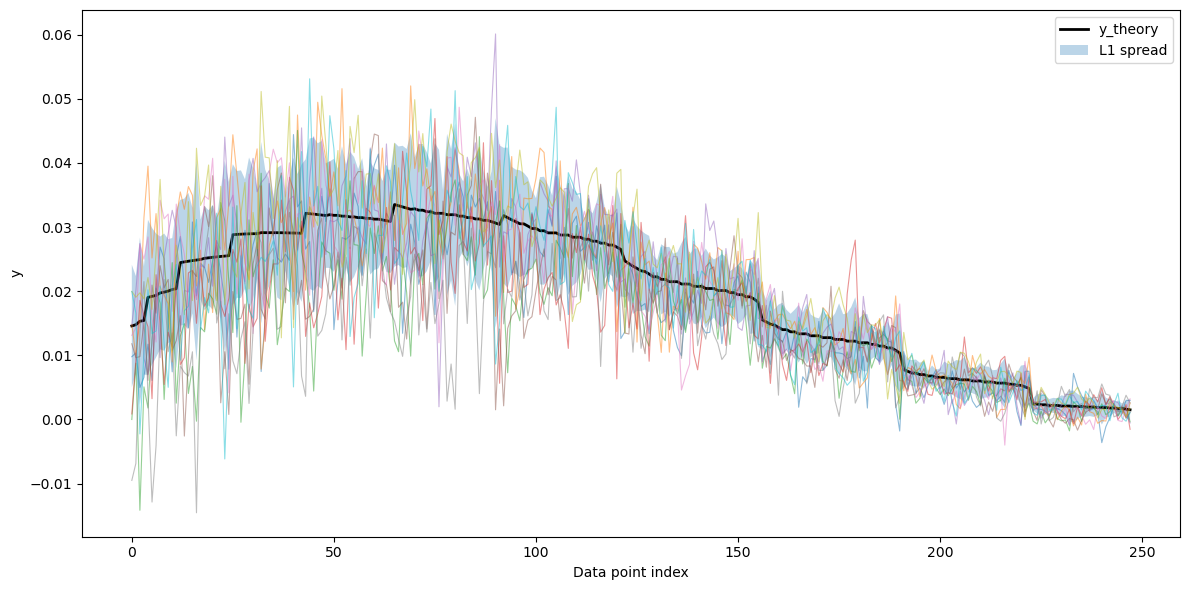

In [15]:
data_idx = np.arange(len(y_theory))

plt.figure(figsize=(12, 6))

plt.plot(data_idx, y_theory, color="black", lw=2, label="y_theory")

plt.fill_between(
    data_idx,
    y_theory - y_l1_std,
    y_theory + y_l1_std,
    alpha=0.3,
    label="L1 spread",
)

for i in range(y_l1_samples.shape[0]):
    plt.plot(data_idx, y_l1_samples[i], lw=0.8, alpha=0.5)

plt.xlabel("Data point index")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

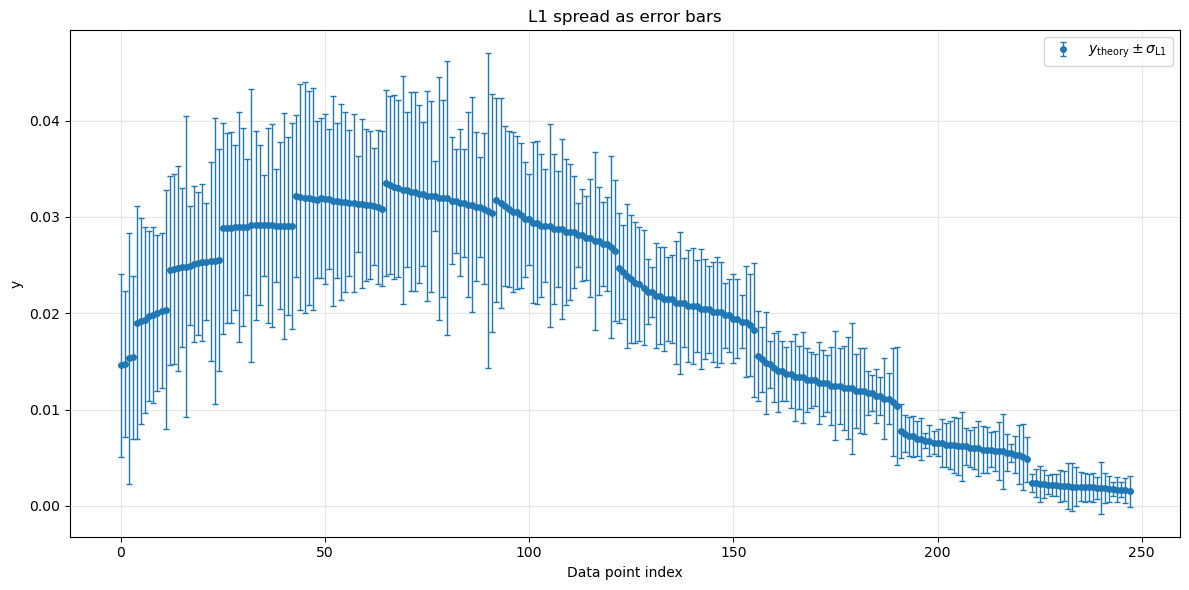

In [16]:
data_idx = np.arange(len(y_theory))

plt.figure(figsize=(12, 6))

plt.errorbar(
    data_idx,
    y_theory,
    yerr=y_l1_std,
    fmt='o',              # points instead of line
    markersize=4,
    capsize=2,
    elinewidth=1,
    label=r"$y_{\mathrm{theory}} \pm \sigma_{\mathrm{L1}}$"
)

plt.xlabel("Data point index")
plt.ylabel("y")
plt.title("L1 spread as error bars")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

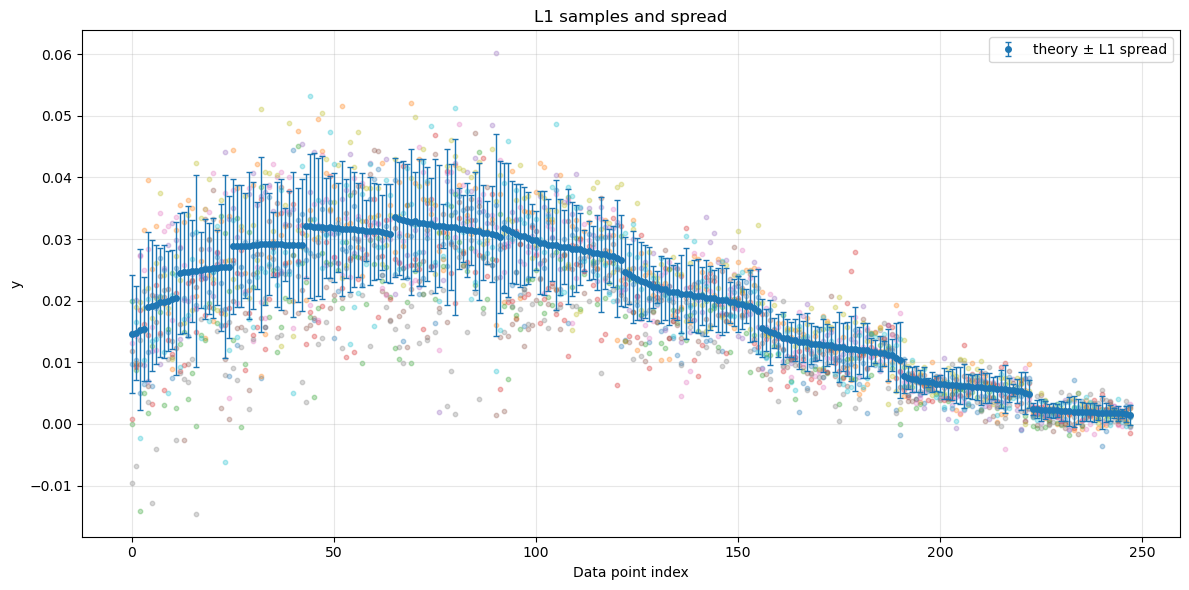

In [17]:
plt.figure(figsize=(12, 6))

# central value with error bars
plt.errorbar(
    data_idx,
    y_theory,
    yerr=y_l1_std,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=1,
    label="theory ± L1 spread"
)

# faint L1 samples
for i in range(y_l1_samples.shape[0]):
    plt.scatter(
        data_idx,
        y_l1_samples[i],
        s=10,
        alpha=0.3,
    )

plt.xlabel("Data point index")
plt.ylabel("y")
plt.title("L1 samples and spread")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

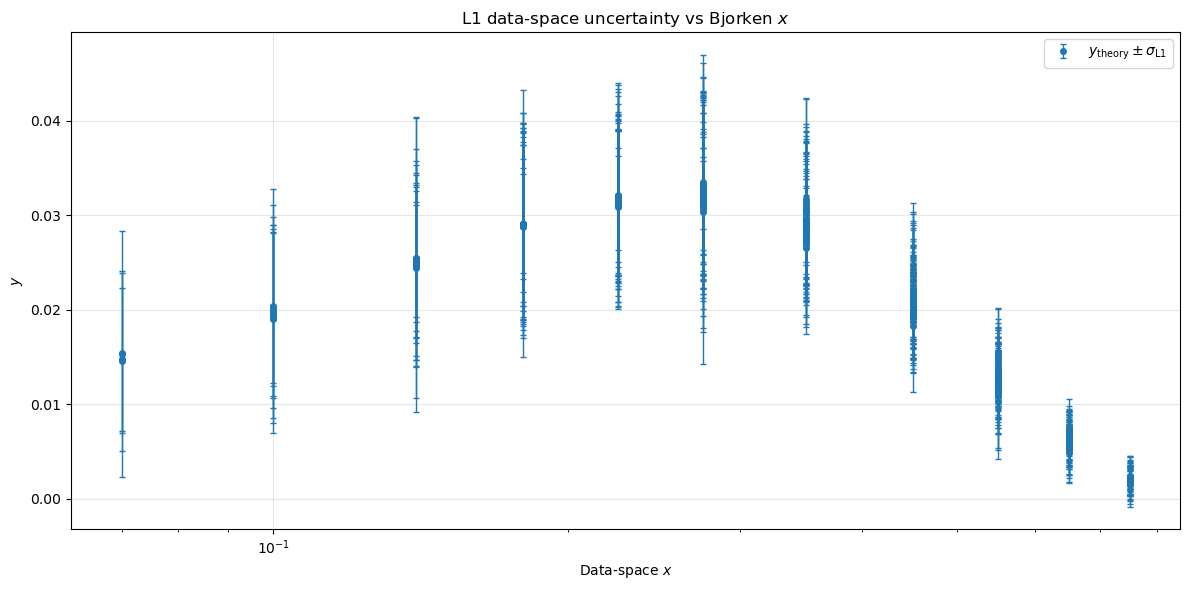

(248,)
(248,)


In [23]:
plt.figure(figsize=(12, 6))

plt.errorbar(
    x_data,
    y_theory,
    yerr=y_l1_std,
    fmt="o",
    markersize=4,
    capsize=2,
    elinewidth=1,
    label=r"$y_{\mathrm{theory}} \pm \sigma_{\mathrm{L1}}$",
)

plt.xlabel(r"Data-space $x$")
plt.ylabel(r"$y$")
plt.title(r"L1 data-space uncertainty vs Bjorken $x$")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(x_data.shape)

print(y_theory.shape)

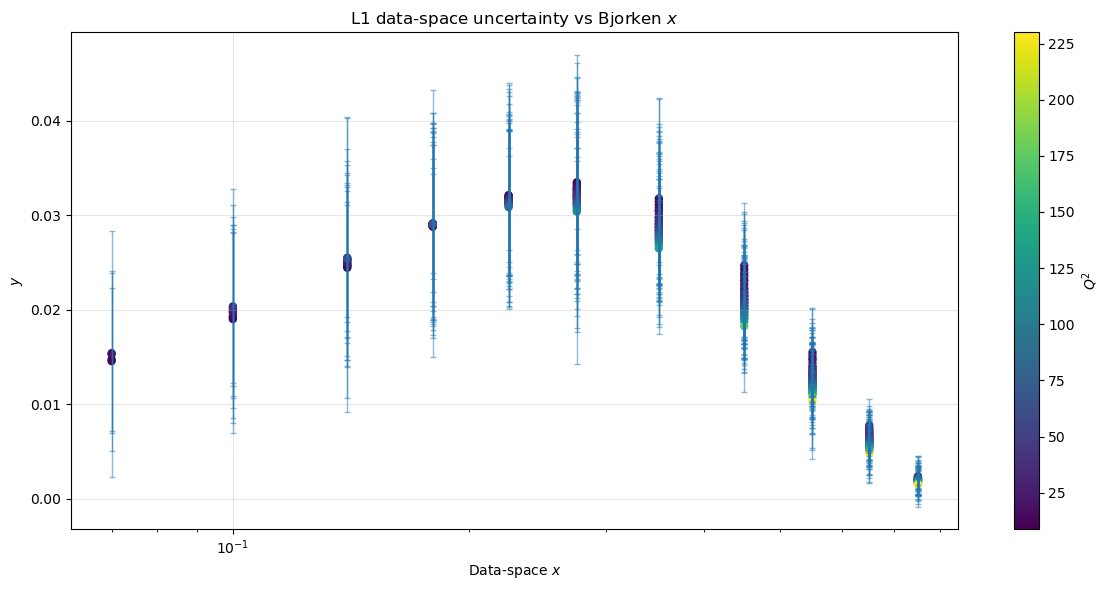

In [ ]:
q2_data = data["q2_vals"]

plt.figure(figsize=(12, 6))

sc = plt.scatter(
    x_data,
    y_theory,
    c=q2_data,
    s=25,
)

plt.errorbar(
    x_data,
    y_theory,
    yerr=y_l1_std,
    fmt="none",
    capsize=2,
    elinewidth=1,
    alpha=0.5,
)

plt.xscale("log")
plt.xlabel(r"Data-space $x$")
plt.ylabel(r"$y$")
plt.title(r"L1 data-space uncertainty vs Bjorken $x$")
plt.colorbar(sc, label=r"$Q^2$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
import numpy as np

def choose_q2_covering_most_x_bins(x_data, q2_data, n_x_bins=11):
    x_data = np.asarray(x_data)
    q2_data = np.asarray(q2_data)

    x_edges = np.geomspace(x_data.min(), x_data.max(), n_x_bins + 1)

    best_q2 = None
    best_n_bins = -1
    best_n_points = -1

    for q2 in np.unique(q2_data):
        mask = q2_data == q2
        occupied_bins = np.unique(
            np.digitize(x_data[mask], x_edges) - 1
        )
        occupied_bins = occupied_bins[
            (occupied_bins >= 0) & (occupied_bins < n_x_bins)
        ]

        n_bins = len(occupied_bins)
        n_points = np.sum(mask)

        if (n_bins > best_n_bins) or (
            n_bins == best_n_bins and n_points > best_n_points
        ):
            best_q2 = q2
            best_n_bins = n_bins
            best_n_points = n_points

    return best_q2, best_n_bins, best_n_points

In [5]:
q2_data = data["q2_vals"]
q2_plot, n_bins_hit, n_points = choose_q2_covering_most_x_bins(
    x_data,
    q2_data,
    n_x_bins=11,
)

print("Chosen Q2:", q2_plot)
print("Occupied x bins:", n_bins_hit, "/ 11")
print("Number of points:", n_points)

Chosen Q2: 37.5
Occupied x bins: 9 / 11
Number of points: 17


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# ============================================================
# Paths
# ============================================================

data_path = Path("../data/Dataset/data_208_extended.npz")

result_paths = {
    "MSE": Path("../results/nn/mse_full/nn_summary.npz"),
    "MSE het": Path("../results/nn/mse_het_full/nn_summary.npz"),
    r"$\chi^2$ het": Path("../results/nn/chi2_full/nn_summary.npz"),
}

outdir = Path("../results/nn/plots")
outdir.mkdir(parents=True, exist_ok=True)

n_x_bins = 11

# ============================================================
# Helper functions
# ============================================================

def get_first_available(npz, keys):
    for key in keys:
        if key in npz.files:
            return np.asarray(npz[key])
    raise KeyError(f"None of these keys found in {npz.files}: {keys}")


def choose_q2_covering_most_x_bins(x_data, q2_data, n_x_bins=11):
    x_data = np.asarray(x_data, dtype=float)
    q2_data = np.asarray(q2_data, dtype=float)

    x_edges = np.geomspace(x_data.min(), x_data.max(), n_x_bins + 1)

    best = None
    rows = []

    for q2 in np.unique(q2_data):
        print("q2: ", q2_data)
        mask = np.isclose(q2_data, q2)

        bin_ids = np.digitize(x_data[mask], x_edges) - 1
        bin_ids = bin_ids[(bin_ids >= 0) & (bin_ids < n_x_bins)]

        n_bins = len(np.unique(bin_ids))
        n_points = np.sum(mask)

        row = {
            "q2": q2,
            "n_bins": n_bins,
            "n_points": n_points,
        }
        rows.append(row)

        if best is None:
            best = row
        elif n_bins > best["n_bins"]:
            best = row
        elif n_bins == best["n_bins"] and n_points > best["n_points"]:
            best = row

    return best, rows


def interpolate_replicas_to_W_grid(summary_xgrid, replicas, target_xgrid):
    summary_xgrid = np.asarray(summary_xgrid, dtype=float)
    target_xgrid = np.asarray(target_xgrid, dtype=float)
    replicas = np.asarray(replicas, dtype=float)

    if replicas.shape[1] == target_xgrid.shape[0] and np.allclose(summary_xgrid, target_xgrid):
        return replicas

    out = np.empty((replicas.shape[0], target_xgrid.shape[0]), dtype=float)

    for i in range(replicas.shape[0]):
        out[i] = np.interp(target_xgrid, summary_xgrid, replicas[i])

    return out


def load_prediction_summary(path):
    summary = np.load(path, allow_pickle=True)

    print(f"\nLoaded {path}")
    print("Available keys:", summary.files)

    return summary

def select_one_point_per_x_bin(x, y, yerr, n_x_bins=11, mode="closest_to_bin_center"):
    x = np.asarray(x)
    y = np.asarray(y)
    yerr = np.asarray(yerr)

    x_edges = np.geomspace(x.min(), x.max(), n_x_bins + 1)
    x_centers = np.sqrt(x_edges[:-1] * x_edges[1:])

    selected_indices = []

    for i in range(n_x_bins):
        in_bin = (x >= x_edges[i]) & (x < x_edges[i + 1])

        # Include right edge in final bin
        if i == n_x_bins - 1:
            in_bin = (x >= x_edges[i]) & (x <= x_edges[i + 1])

        idx = np.where(in_bin)[0]

        if len(idx) == 0:
            continue

        if mode == "closest_to_bin_center":
            chosen = idx[np.argmin(np.abs(np.log(x[idx]) - np.log(x_centers[i])))]
        elif mode == "smallest_error":
            chosen = idx[np.argmin(yerr[idx])]
        elif mode == "first":
            chosen = idx[0]
        else:
            raise ValueError(f"Unknown mode: {mode}")

        selected_indices.append(chosen)

    selected_indices = np.asarray(selected_indices)

    return (
        x[selected_indices],
        y[selected_indices],
        yerr[selected_indices],
        selected_indices,
    )


def compute_data_space_prediction(result_path, W=None, xgrid_W=None):
    summary = load_prediction_summary(result_path)

    # ------------------------------------------------------------
    # Case 1: summary already contains data-space predictions
    # ------------------------------------------------------------
    if "y_pred_members" in summary.files:
        Y_members = np.asarray(summary["y_pred_members"], dtype=float)

        y_mean = (
            np.asarray(summary["y_pred_mean"], dtype=float)
            if "y_pred_mean" in summary.files
            else Y_members.mean(axis=0)
        )

        y_epistemic_var = Y_members.var(axis=0, ddof=1)
        y_epistemic_sigma = np.sqrt(np.maximum(y_epistemic_var, 0.0))

        if "sigma2_het_xg" in summary.files:
            y_aleatoric_var = np.asarray(summary["sigma2_het_xg"], dtype=float)
        elif "hetC" in summary.files:
            y_aleatoric_var = np.diag(np.asarray(summary["hetC"], dtype=float))
        else:
            y_aleatoric_var = np.zeros_like(y_epistemic_var)

        y_aleatoric_sigma = np.sqrt(np.maximum(y_aleatoric_var, 0.0))

        if "diagC" in summary.files:
            y_total_sigma = np.sqrt(np.maximum(np.asarray(summary["diagC"], dtype=float), 0.0))
        elif "totalC" in summary.files:
            y_total_sigma = np.sqrt(np.maximum(np.diag(np.asarray(summary["totalC"], dtype=float)), 0.0))
        else:
            y_total_sigma = np.sqrt(np.maximum(y_epistemic_var + y_aleatoric_var, 0.0))

        return {
            "y_mean": y_mean,
            "y_epistemic_sigma": y_epistemic_sigma,
            "y_aleatoric_sigma": y_aleatoric_sigma,
            "y_total_sigma": y_total_sigma,
            "has_het_uncertainty": np.any(y_aleatoric_var > 0),
            "source": "data-space y_pred_members",
        }

    # ------------------------------------------------------------
    # Case 2: older/raw format with grid-space replicas
    # ------------------------------------------------------------
    if "replicas" in summary.files:
        if W is None or xgrid_W is None:
            raise ValueError("W and xgrid_W are required when using grid-space replicas.")

        replicas = np.asarray(summary["replicas"], dtype=float)
        summary_xgrid = np.asarray(summary["xgrid"], dtype=float)

        vars_replicas = None
        if "vars_replicas" in summary.files:
            arr = summary["vars_replicas"]
            if arr is not None and np.asarray(arr).shape != ():
                vars_replicas = np.asarray(arr, dtype=float)

        replicas_W = interpolate_replicas_to_W_grid(
            summary_xgrid=summary_xgrid,
            replicas=replicas,
            target_xgrid=xgrid_W,
        )

        Y_members = replicas_W @ W.T
        y_mean = Y_members.mean(axis=0)

        y_epistemic_var = Y_members.var(axis=0, ddof=1)
        y_epistemic_sigma = np.sqrt(np.maximum(y_epistemic_var, 0.0))

        if vars_replicas is not None:
            vars_replicas_W = interpolate_replicas_to_W_grid(
                summary_xgrid=summary_xgrid,
                replicas=vars_replicas,
                target_xgrid=xgrid_W,
            )
            Y_var_members = vars_replicas_W @ (W.T ** 2)
            y_aleatoric_var = Y_var_members.mean(axis=0)
        else:
            y_aleatoric_var = np.zeros_like(y_epistemic_var)

        y_aleatoric_sigma = np.sqrt(np.maximum(y_aleatoric_var, 0.0))
        y_total_sigma = np.sqrt(np.maximum(y_epistemic_var + y_aleatoric_var, 0.0))

        return {
            "y_mean": y_mean,
            "y_epistemic_sigma": y_epistemic_sigma,
            "y_aleatoric_sigma": y_aleatoric_sigma,
            "y_total_sigma": y_total_sigma,
            "has_het_uncertainty": vars_replicas is not None,
            "source": "grid-space replicas",
        }

    raise KeyError(
        f"Could not find either 'y_pred_members' or 'replicas' in {result_path}. "
        f"Available keys are: {summary.files}"
    )


# ============================================================
# Load dataset
# ============================================================



q2 data:  23

Loaded ../results/nn/mse_full/nn_summary.npz
Available keys: ['xgrid', 'mean_curve', 'xt3_true_star', 'true_sigma', 'var_ens', 'var_het', 'y_target', 'y_pred_mean', 'sigma2_ens_xg', 'sigma2_het_xg', 'diagC', 'ensC', 'hetC', 'totalC', 'sigma_xg', 'cov_ens_f', 'xgrid_cov_ens_f', 'cov_het_f', 'cov_tot_f', 'sigma_f', 'y_pred_members', 'mus', 'vars']


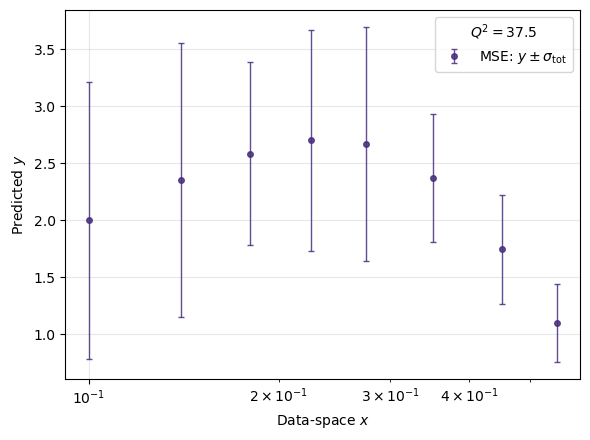


MSE
  Saved: ../results/nn/plots/prediction_fixed_q2_MSE.pdf
  Points plotted: 8 / 11
  Has heteroscedastic uncertainty: False
  Mean ensemble sigma on slice: 0.0318497
  Mean het sigma on slice:      0
  Mean total sigma on slice:    0.823758

Loaded ../results/nn/mse_het_full/nn_summary.npz
Available keys: ['xgrid', 'mean_curve', 'xt3_true_star', 'true_sigma', 'var_ens', 'var_het', 'y_target', 'y_pred_mean', 'sigma2_ens_xg', 'sigma2_het_xg', 'diagC', 'ensC', 'hetC', 'totalC', 'sigma_xg', 'cov_ens_f', 'xgrid_cov_ens_f', 'cov_het_f', 'cov_tot_f', 'sigma_f', 'y_pred_members', 'mus', 'vars']


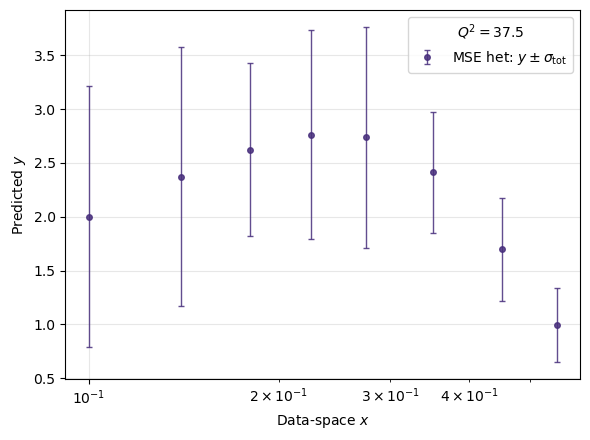


MSE het
  Saved: ../results/nn/plots/prediction_fixed_q2_MSE_het.pdf
  Points plotted: 8 / 11
  Has heteroscedastic uncertainty: True
  Mean ensemble sigma on slice: 0.0346381
  Mean het sigma on slice:      0.578936
  Mean total sigma on slice:    0.823758

Loaded ../results/nn/chi2_full/nn_summary.npz
Available keys: ['xgrid', 'mean_curve', 'xt3_true_star', 'true_sigma', 'var_ens', 'var_het', 'y_target', 'y_pred_mean', 'sigma2_ens_xg', 'sigma2_het_xg', 'diagC', 'ensC', 'hetC', 'totalC', 'sigma_xg', 'cov_ens_f', 'xgrid_cov_ens_f', 'cov_het_f', 'cov_tot_f', 'sigma_f', 'y_pred_members', 'mus', 'vars']


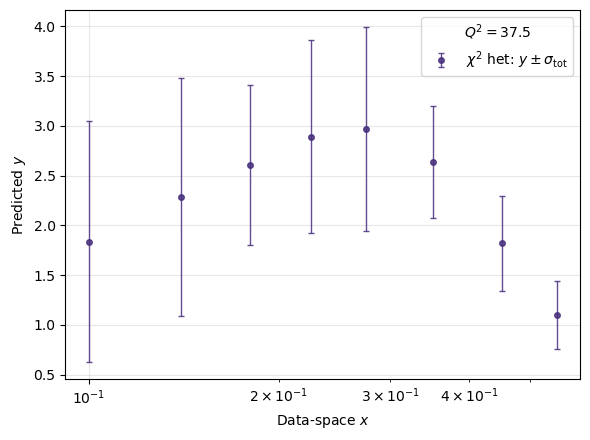


$\chi^2$ het
  Saved: ../results/nn/plots/prediction_fixed_q2_chi2_het.pdf
  Points plotted: 8 / 11
  Has heteroscedastic uncertainty: False
  Mean ensemble sigma on slice: 0.0495424
  Mean het sigma on slice:      0
  Mean total sigma on slice:    0.823758

Loaded ../results/nn/mse_full/nn_summary.npz
Available keys: ['xgrid', 'mean_curve', 'xt3_true_star', 'true_sigma', 'var_ens', 'var_het', 'y_target', 'y_pred_mean', 'sigma2_ens_xg', 'sigma2_het_xg', 'diagC', 'ensC', 'hetC', 'totalC', 'sigma_xg', 'cov_ens_f', 'xgrid_cov_ens_f', 'cov_het_f', 'cov_tot_f', 'sigma_f', 'y_pred_members', 'mus', 'vars']

Loaded ../results/nn/mse_het_full/nn_summary.npz
Available keys: ['xgrid', 'mean_curve', 'xt3_true_star', 'true_sigma', 'var_ens', 'var_het', 'y_target', 'y_pred_mean', 'sigma2_ens_xg', 'sigma2_het_xg', 'diagC', 'ensC', 'hetC', 'totalC', 'sigma_xg', 'cov_ens_f', 'xgrid_cov_ens_f', 'cov_het_f', 'cov_tot_f', 'sigma_f', 'y_pred_members', 'mus', 'vars']

Loaded ../results/nn/chi2_full/nn_summ

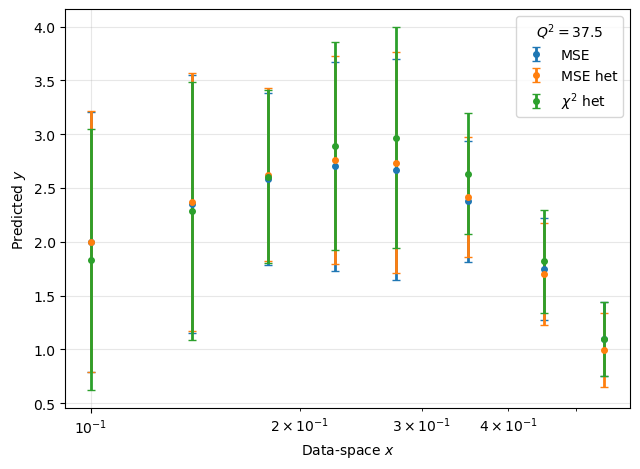


Saved combined plot: ../results/nn/plots/prediction_fixed_q2_all_models.pdf


In [21]:
# ============================================================
# Select fixed-Q2 data slice
# ============================================================

mask_q2 = np.isclose(q2_data, q2_plot)
print("q2 data: ", len(np.unique(q2_data)))
x_q2 = x_data[mask_q2]

# For coloring with the same convention as your previous plots
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=np.min(q2_data), vmax=np.max(q2_data))
q2_color = cmap(norm(q2_plot))

# ============================================================
# Plot all three models separately
# ============================================================

for label, result_path in result_paths.items():
    pred = compute_data_space_prediction(
        result_path=result_path,
        W=W,
        xgrid_W=xgrid_W,
    )

    y_q2 = pred["y_mean"][mask_q2]
    sigma_q2 = pred["y_total_sigma"][mask_q2]
    sigma_ens_q2 = pred["y_epistemic_sigma"][mask_q2]
    sigma_het_q2 = pred["y_aleatoric_sigma"][mask_q2]

    x_sel, y_sel, sigma_tot_sel, selected_local_idx = select_one_point_per_x_bin(
        x=x_q2,
        y=y_q2,
        yerr=sigma_q2,
        n_x_bins=11,
        mode="closest_to_bin_center",
    )

    sigma_ens_sel = sigma_ens_q2[selected_local_idx]
    sigma_het_sel = sigma_het_q2[selected_local_idx]

    order = np.argsort(x_sel)

    x_sel = x_sel[order]
    y_sel = y_sel[order]
    sigma_tot_sel = sigma_tot_sel[order]
    sigma_ens_sel = sigma_ens_sel[order]
    sigma_het_sel = sigma_het_sel[order]

    fig, ax = plt.subplots(figsize=(6, 4.5))

    ax.errorbar(
        x_sel,
        y_sel,
        yerr=sigma_tot_sel,
        fmt="o",
        color=q2_color,
        capsize=2,
        elinewidth=1,
        markersize=4,
        alpha=0.85,
        label=rf"{label}: $y \pm \sigma_\mathrm{{tot}}$",
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"Data-space $x$")
    ax.set_ylabel(r"Predicted $y$")
    ax.grid(alpha=0.3)
    ax.legend(title=rf"$Q^2 = {q2_plot:.3g}$")

    fig.tight_layout()

    safe_label = (
        label.replace("$", "")
        .replace("\\", "")
        .replace("^", "")
        .replace(" ", "_")
        .replace("{", "")
        .replace("}", "")
    )

    save_path = outdir / f"prediction_fixed_q2_{safe_label}.pdf"
    fig.savefig(save_path)
    plt.show()
    plt.close()

    print(f"\n{label}")
    print(f"  Saved: {save_path}")
    print(f"  Points plotted: {len(x_sel)} / {n_x_bins}")
    print(f"  Has heteroscedastic uncertainty: {pred['has_het_uncertainty']}")
    print(f"  Mean ensemble sigma on slice: {np.mean(sigma_ens_sel):.6g}")
    print(f"  Mean het sigma on slice:      {np.mean(sigma_het_sel):.6g}")
    print(f"  Mean total sigma on slice:    {np.mean(sigma_tot_sel):.6g}")

# ============================================================
# Optional: combined comparison plot
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 4.8))

for label, result_path in result_paths.items():
    pred = compute_data_space_prediction(
        result_path=result_path,
        W=W,
        xgrid_W=xgrid_W,
    )

    y_q2 = pred["y_mean"][mask_q2]
    sigma_q2 = pred["y_total_sigma"][mask_q2]

    x_sel, y_sel, sigma_tot_sel, selected_local_idx = select_one_point_per_x_bin(
        x=x_q2,
        y=y_q2,
        yerr=sigma_q2,
        n_x_bins=11,
        mode="closest_to_bin_center",
    )

    order = np.argsort(x_sel)

    ax.errorbar(
        x_sel[order],
        y_sel[order],
        yerr=sigma_tot_sel[order],
        fmt="o",
        capsize=3,
        elinewidth=2,
        markersize=4,
        label=label,
    )

ax.set_xscale("log")
ax.set_xlabel(r"Data-space $x$")
ax.set_ylabel(r"Predicted $y$")
ax.grid(alpha=0.3)
ax.legend(title=rf"$Q^2 = {q2_plot:.3g}$")

fig.tight_layout()

combined_save_path = outdir / "prediction_fixed_q2_all_models.pdf"
fig.savefig(combined_save_path)
plt.show()
plt.close()

print(f"\nSaved combined plot: {combined_save_path}")